# Install Libraries

In [1]:
!pip install -q diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.4 MB/s eta 0:00:00


# Import Required Modules

In [2]:
import torch
from diffusers import StableDiffusionXLPipeline, AutoencoderKL, EulerDiscreteScheduler
import matplotlib.pyplot as plt
from PIL import Image
import os, zipfile
from IPython.display import display

2025-11-22 18:18:41.121179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763835521.345389      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763835521.407184      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load SDXL Model and VAE

In [3]:
model_path = "/kaggle/input/stable-diffusion-xl/pytorch/base-1-0/1"
vae_path = f"{model_path}/vae"

pipe = StableDiffusionXLPipeline.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

vae = AutoencoderKL.from_pretrained(
    vae_path,
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")

pipe.vae = vae

pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

# Configurations

In [4]:
prompts = [
    "a cyberpunk Tokyo street at night, neon lights, rain",
    "a medieval castle on a mountain, fantasy art",
    "a futuristic astronaut exploring an alien jungle, cinematic, 4K"
]

negative_prompt = "blurry, low quality, distorted, watermark"
output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)


# Generation Loop

Generating: a cyberpunk Tokyo street at night, neon lights, rain


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: a medieval castle on a mountain, fantasy art


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: a futuristic astronaut exploring an alien jungle, cinematic, 4K


  0%|          | 0/50 [00:00<?, ?it/s]

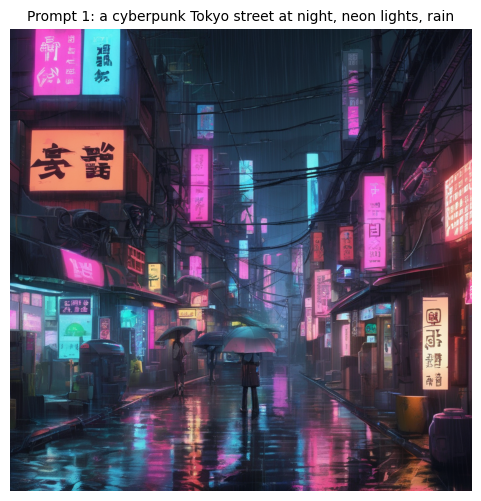

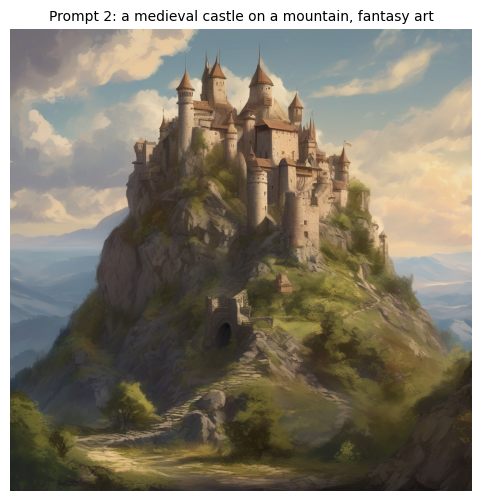

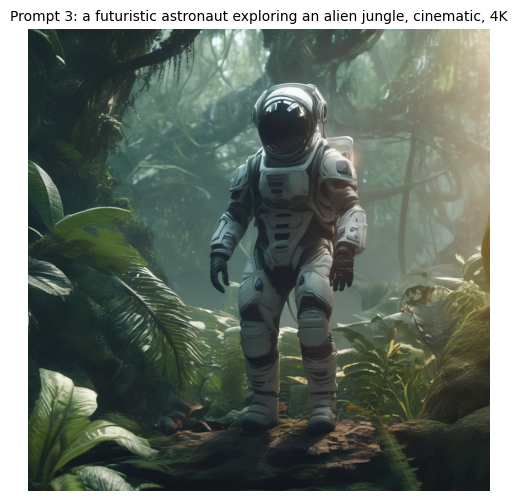

In [5]:
images = []
for idx, prompt in enumerate(prompts):
    print(f"Generating: {prompt}")
    with torch.inference_mode():
        image = pipe(prompt=prompt, negative_prompt=negative_prompt).images[0]
        images.append((prompt, image))
        image.save(f"{output_dir}/image_{idx+1}.png")

for i, (prompt, img) in enumerate(images):
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prompt {i+1}: {prompt}", fontsize=10)
    plt.show()